Step 1: Load & Initial EDA — Understanding the Political Landscape

Goal: Before any LGBTQ+ filtering, understand the partisan "atmosphere" 
of each state-session from the full 750k bill dataset.

In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
# Read in Bills Data
df = pd.read_csv('../../datasources/final-outputs/all_bills_2021_2026.csv',
                 engine='python', # ishanis edits
                 on_bad_lines='skip',) # ishanis edits — added b/c of error below)

In [3]:
print(f"Total bills: {len(df):,}")
print(f"States: {df['state'].nunique()}")
print(f"\nColumns:\n{df.dtypes}")

Total bills: 746,423
States: 53

Columns:
state                  object
bill_id                 int64
session_id              int64
bill_number            object
status                  int64
status_desc            object
status_date            object
title                  object
description            object
committee_id            int64
committee              object
last_action_date       object
last_action            object
url                    object
state_link             object
sponsor_names          object
sponsor_parties        object
primary_sponsor        object
sponsor_count           int64
action_count            int64
last_history_action    object
document_count          int64
document_types         object
document_urls          object
rollcall_count          int64
total_yea               int64
total_nay               int64
dtype: object


In [4]:
# Data quality checks
print("\n--- Missing Values (top columns) ---")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(15))

print("\n--- Status Distribution ---")
print(df['status_desc'].value_counts())

print("\n--- Bills per State (top 10) ---")
print(df['state'].value_counts().head(10))

df['year'] = pd.to_datetime(df['status_date']).dt.year
df['year'] = df['year'].fillna(df['year']).astype('Int64')


--- Missing Values (top columns) ---
committee              334389
sponsor_parties         28484
primary_sponsor          4666
sponsor_names            4662
document_types           2862
document_urls            2862
status_desc              1361
status_date              1361
last_action               664
last_history_action       657
last_action_date          656
title                       1
dtype: int64

--- Status Distribution ---
status_desc
Introduced    474259
Passed        168104
Failed         50394
Engrossed      45691
Vetoed          4309
Enrolled        2305
Name: count, dtype: int64

--- Bills per State (top 10) ---
state
NY            68400
NJ            65270
TX            37746
USCongress    37121
IL            34278
HI            29419
MN            28006
OK            27008
TN            26147
MA            24673
Name: count, dtype: int64


In [5]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D'))
    }
    return counts


# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['bill_dominant_party'] = df.apply(dominant_party, axis=1)

print("\n--- Bill Dominant Party Distribution ---")
print(df['bill_dominant_party'].value_counts())
print(f"\nBipartisan bills: {(df['bill_dominant_party'] == 'Bipartisan').sum():,} "
      f"({(df['bill_dominant_party'] == 'Bipartisan').mean():.1%})")


--- Bill Dominant Party Distribution ---
bill_dominant_party
D             375541
R             307111
Other          34434
Bipartisan     29337
Name: count, dtype: int64

Bipartisan bills: 29,337 (3.9%)


In [6]:
df['passed'] = df['status'].isin([4])  # Only fully passed
df['failed'] = df['status'].isin([6])
df['vetoed'] = df['status'].isin([5])

print("\n--- Overall Pass Rates ---")
print(f"Passed: {df['passed'].mean():.1%}")
print(f"Failed/Dead: {df['failed'].mean():.1%}")
print(f"Vetoed: {df['vetoed'].mean():.1%}")
print(
    f"Still in process / other: {(~df['passed'] & ~df['failed'] & ~df['vetoed']).mean():.1%}")

# Pass rate by dominant party
print("\n--- Pass Rate by Bill's Dominant Party ---")
print(df.groupby('bill_dominant_party')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('n_bills', ascending=False))


--- Overall Pass Rates ---
Passed: 22.5%
Failed/Dead: 6.8%
Vetoed: 0.6%
Still in process / other: 70.2%

--- Pass Rate by Bill's Dominant Party ---
                     pass_rate  n_bills
bill_dominant_party                    
D                     0.195627   375541
R                     0.251258   307111
Other                 0.324824    34434
Bipartisan            0.214371    29337


In [7]:
print("\n--- Sample Bills with Parsed Sponsors ---")
cols_to_show = ['year', 'state', 'bill_number', 'title', 'status_desc',
                'r_sponsors', 'd_sponsors', 'bill_dominant_party', 'sponsor_count']
print(df[cols_to_show].head(10).to_string(index=False))


--- Sample Bills with Parsed Sponsors ---
 year state bill_number                                     title status_desc  r_sponsors  d_sponsors bill_dominant_party  sponsor_count
 2021    AK         HB1                  Audit Of Cares Act Funds  Introduced           5           1                   R              6
 2021    AK         HB2      Minimum Age To Sell Tobacco/nicotine  Introduced           1           0                   R              1
 2022    AK         HB3   Definition Of "disaster": Cybersecurity      Passed           8           1                   R             10
 2021    AK         HB4  Business/prof. License Immunity Covid-19  Introduced           7           0                   R              7
 2021    AK         HB5         Sexual Assault; Def. Of "consent"  Introduced           2          10                   D             13
 <NA>    AK         HB6                            Not Introduced         NaN           0           0               Other              

Step 2: State-Session Political Profiles

Goal: For each state-year, compute a political "atmosphere" profile
that captures partisan lean, legislative activity, and pass dynamics.

In [8]:
state_year_profiles = df.groupby(['state', 'year']).agg(
    # --- Volume ---
    total_bills=('bill_id', 'count'),

    # --- Partisan Sponsorship ---
    r_sponsored_bills=('bill_dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('bill_dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('bill_dominant_party',
                      lambda x: (x == 'Bipartisan').sum()),

    # --- Pass Rates ---
    total_passed=('passed', 'sum'),

    # --- Sponsor Counts (avg engagement) ---
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

# --- Derived Ratios ---

# Partisan lean: ratio of R-sponsored to total partisan bills
# Values > 0.5 = R-leaning legislature, < 0.5 = D-leaning
state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)  # Handle edge cases

# Overall pass rate
state_year_profiles['overall_pass_rate'] = (
    state_year_profiles['total_passed'] /
    state_year_profiles['total_bills']
)

# Bipartisan ratio: what fraction of bills have mixed sponsorship
state_year_profiles['bipartisan_ratio'] = (
    state_year_profiles['bipartisan_bills'] /
    state_year_profiles['total_bills']
)

print("\n--- State-Year Profile Sample ---")
cols = ['state', 'year', 'total_bills', 'r_sponsorship_ratio',
        'overall_pass_rate', 'bipartisan_ratio']
print(state_year_profiles[cols].head(10).to_string(index=False))


--- State-Year Profile Sample ---
state  year  total_bills  r_sponsorship_ratio  overall_pass_rate  bipartisan_ratio
   AK  2021          396             0.528302           0.123737          0.037879
   AK  2022          429             0.569930           0.256410          0.025641
   AK  2023          347             0.541485           0.129683          0.040346
   AK  2024          444             0.596296           0.182432          0.022523
   AK  2025          506             0.480938           0.108696          0.043478
   AK  2026           96             0.559322           0.010417          0.020833
   AL  2021         1614             0.821381           0.486369          0.021685
   AL  2022         1285             0.775200           0.499611          0.007782
   AL  2023         1323             0.780801           0.482237          0.000000
   AL  2024         1220             0.745180           0.534426          0.000000


In [9]:
def pass_rate_by_party(group):
    r_bills = group[group['bill_dominant_party'] == 'R']
    d_bills = group[group['bill_dominant_party'] == 'D']
    return pd.Series({
        'r_pass_rate': r_bills['passed'].mean() if len(r_bills) > 0 else np.nan,
        'd_pass_rate': d_bills['passed'].mean() if len(d_bills) > 0 else np.nan,
        'r_bill_count': len(r_bills),
        'd_bill_count': len(d_bills),
    })


party_pass = df.groupby(['state', 'year']).apply(
    pass_rate_by_party, include_groups=False
).reset_index()

# Merge into profiles
state_year_profiles = state_year_profiles.merge(
    party_pass, on=['state', 'year'])

# Pass rate gap: positive = R bills pass more, negative = D bills pass more
state_year_profiles['pass_rate_gap'] = (
    state_year_profiles['r_pass_rate'] - state_year_profiles['d_pass_rate']
)

print("\n--- Pass Rate Gap Distribution ---")
print(state_year_profiles['pass_rate_gap'].describe())


--- Pass Rate Gap Distribution ---
count    297.000000
mean       0.025928
std        0.195295
min       -0.774764
25%       -0.060872
50%        0.003738
75%        0.141207
max        0.553203
Name: pass_rate_gap, dtype: float64


In [10]:
def classify_state_lean(row):
    """
    Weight sponsorship ratio more heavily,
    use pass rate gap as secondary signal.
    """
    r_ratio = row['r_sponsorship_ratio']
    gap = row['pass_rate_gap']

    # Primary signal: who's introducing legislation
    if r_ratio > 0.7:
        return 'Strong R'
    elif r_ratio > 0.55:
        # Check if gap confirms or contradicts
        return 'Strong R' if gap > 0.1 else 'Lean R'
    elif r_ratio < 0.3:
        return 'Strong D'
    elif r_ratio < 0.45:
        return 'Strong D' if gap < -0.1 else 'Lean D'
    else:
        # True competitive: 0.45-0.55 sponsorship ratio
        if gap > 0.1:
            return 'Lean R'
        elif gap < -0.1:
            return 'Lean D'
        return 'Competitive'


state_year_profiles['state_lean'] = state_year_profiles.apply(
    classify_state_lean, axis=1)

print("\n--- State Lean Distribution ---")
print(state_year_profiles['state_lean'].value_counts())

# Show some examples
print("\n--- Example Strong R States ---")
strong_r = state_year_profiles[state_year_profiles['state_lean'] == 'Strong R']
print(strong_r[['state', 'year', 'r_sponsorship_ratio', 'pass_rate_gap']]
      .sort_values('pass_rate_gap', ascending=False).head(10).to_string(index=False))

print("\n--- Example Strong D States ---")
strong_d = state_year_profiles[state_year_profiles['state_lean'] == 'Strong D']
print(strong_d[['state', 'year', 'r_sponsorship_ratio', 'pass_rate_gap']]
      .sort_values('pass_rate_gap').head(10).to_string(index=False))


--- State Lean Distribution ---
state_lean
Strong R       114
Strong D       105
Lean R          44
Competitive     26
Lean D          26
Name: count, dtype: int64

--- Example Strong R States ---
state  year  r_sponsorship_ratio  pass_rate_gap
   UT  2022             0.886872       0.553203
   UT  2024             0.893921       0.527640
   UT  2023             0.886499       0.491446
   UT  2025             0.903737       0.459354
   OH  2026             0.831169       0.455529
   UT  2021             0.887770       0.443025
   ID  2023             0.842697       0.426667
   SD  2024             0.866029       0.418607
   ND  2021             0.880403       0.410250
   KS  2025             0.590604       0.400335

--- Example Strong D States ---
state  year  r_sponsorship_ratio  pass_rate_gap
   CO  2023             0.105185      -0.774764
   CO  2024             0.084088      -0.754694
   CO  2022             0.156835      -0.721593
   CO  2021             0.137195      -0.714684
 

In [11]:
print("\n--- Sanity Check: Known States (most recent year) ---")
latest = state_year_profiles.sort_values('year').groupby('state').last()
print(latest[['year', 'r_sponsorship_ratio', 'pass_rate_gap', 'state_lean']]
      .sort_values('r_sponsorship_ratio', ascending=False)
      .to_string())


--- Sanity Check: Known States (most recent year) ---
            year  r_sponsorship_ratio  pass_rate_gap   state_lean
state                                                            
ND          2026             1.000000       0.228060     Strong R
WY          2025             0.976303       0.264563     Strong R
WV          2026             0.958716       0.014952     Strong R
ID          2026             0.947368       0.000000     Strong R
SD          2026             0.920110       0.000000     Strong R
AR          2025             0.906231       0.225150     Strong R
OK          2026             0.876281       0.000000     Strong R
TN          2026             0.848993       0.010277     Strong R
UT          2026             0.844904       0.006993     Strong R
IA          2026             0.842105       0.000000     Strong R
NH          2026             0.840000       0.000000     Strong R
OH          2026             0.831169       0.455529     Strong R
SC          2026     

In [12]:
# Merge key state-year profile columns into the main bills DataFrame
# so they're available after the ACLU merge for profiling
profile_cols = ['state', 'year', 'state_lean', 'r_sponsorship_ratio',
                'pass_rate_gap', 'overall_pass_rate', 'bipartisan_ratio']

df = df.merge(
    state_year_profiles[profile_cols],
    on=['state', 'year'],
    how='left'
)

print(f"Merged state-year profiles into df")
print(f"  state_lean coverage: {df['state_lean'].notna().sum():,} / {len(df):,} "
      f"({df['state_lean'].notna().mean():.1%})")
print(f"\n  state_lean distribution in df:")
print(df['state_lean'].value_counts().to_string())

Merged state-year profiles into df
  state_lean coverage: 745,062 / 746,423 (99.8%)

  state_lean distribution in df:
state_lean
Strong D       267629
Strong R       183090
Lean D         119991
Competitive     93360
Lean R          80992


In [13]:
# Load the unified LGBTQ+ bills dataset (ACLU + Plural merged)
lgbtq = pd.read_csv('../../datasources/final-outputs/all_lgbtq_bills_merged.csv')

print(f"LegiScan bills: {len(df):,}")
print(f"LGBTQ+ labeled bills: {len(lgbtq):,}")
print(f"  Sources: {lgbtq['source'].value_counts().to_dict()}")
print(f"  Labels:  {lgbtq['label'].value_counts().to_dict()}")
print(f"  States:  {lgbtq['state'].nunique()}")
lgbtq.head()

LegiScan bills: 746,423
LGBTQ+ labeled bills: 2,312
  Sources: {'aclu': 1977, 'plural': 335}
  Labels:  {'harmful': 2048, 'supportive': 264}
  States:  51


,year,state,bill_name,bill_number,issues,label,source,status,status_detail,status_date,description,sponsors
0,2021,AL,SB 10,SB10,Anti-Trans bills | Prohibiting heathcare for t...,harmful,aclu,Introduced,Died,NaN,NaN,NaN
1,2025,MI,H.B.4777,HB4777,Other civil rights restrictions | Weakening Ci...,harmful,aclu,Advancing,First read and referred to committee,2025-08-20,NaN,NaN
2,2025,MI,H.B.4829,HB4829,Religious exemptions | Weakening Civil Rights ...,harmful,aclu,Advancing,First read and referred to committee,2025-08-27,NaN,NaN
3,2025,MI,H.B.4024,HB4024,Restricting student & educator rights | School...,harmful,aclu,Advancing,Passed House; Senate referred to committee,2025-09-09,NaN,NaN
4,2025,MI,H.B.4576,HB4576,Curriculum censorship | Other school restricti...,harmful,aclu,Advancing,Passed House; Senate referred to committee,2025-06-12,NaN,NaN


In [14]:
df['session_year'] = df['url'].str.extract(r'/(\d{4})$')[0].astype('Int64')
df['year'] = df['year'].astype('Int64')
df['session_year'] = df['session_year'].fillna(df['year']).astype('Int64')
lgbtq['year'] = lgbtq['year'].astype('Int64')

# --- Deduplicate: same bill tracked across multiple sources/years ---
lgbtq_dedup = (lgbtq.sort_values(['source', 'year'])  # prefer aclu source first
               .drop_duplicates(['state', 'bill_number'], keep='first')
               .copy())

print(f"Session year coverage: {df['session_year'].notna().sum():,} / {len(df):,}")
print(f"Session year range: {df['session_year'].min()} - {df['session_year'].max()}")
print(f"\nLGBTQ+ total rows: {len(lgbtq)}")
print(f"LGBTQ+ unique bills (after dedup): {len(lgbtq_dedup)}")
print(f"Duplicates removed: {len(lgbtq) - len(lgbtq_dedup)}")
print(f"\nDeduped label split:\n{lgbtq_dedup['label'].value_counts()}")

Session year coverage: 746,403 / 746,423
Session year range: 2020 - 2026

LGBTQ+ total rows: 2312
LGBTQ+ unique bills (after dedup): 2312
Duplicates removed: 0

Deduped label split:
label
harmful       2048
supportive     264
Name: count, dtype: int64


In [15]:
# merged = df.merge(
#     aclu_dedup[['state', 'year', 'bill_number', 'label']],
#     on=['state', 'year', 'bill_number'],
#     how='left'
# )

# merged['label_source'] = merged['label'].apply(
#     lambda x: 'aclu' if pd.notna(x) else None
# )

# n_matched = merged['label'].notna().sum()
# print(
#     f"Matched: {n_matched} / {len(aclu_dedup)} ({n_matched/len(aclu_dedup):.1%})")


In [16]:
# don't change this function
def static_remove_leading_zeros(bill_number):
    # Split into letter prefix and numeric part, strip leading zeros from number
    match = re.match(r'([A-Za-z]+)(0*)(\d+)', bill_number)
    if match:
        letters, _, digits = match.groups()
        return f"{letters}{int(digits)}"
    return bill_number



def replace_bill_prefixes(bill_number):
    bill_number = bill_number.replace('HB', 'H')
    bill_number = bill_number.replace('SB', 'S')
    return bill_number

In [17]:
# bill no. cleaners for four missing states


# VT
# two bills not matched from this alone (7/9 correct)
df.loc[df['state'] == 'VT', 'bill_number'] = (
        df.loc[df['state'] == 'VT', 'bill_number'].apply(static_remove_leading_zeros)
    )

# FL
# five bills not matched and many doubles within the year (~45/50 correct)
df.loc[df['state'] == 'FL', 'bill_number'] = (
        df.loc[df['state'] == 'FL', 'bill_number'].apply(static_remove_leading_zeros)
    )
lgbtq_dedup.loc[lgbtq_dedup['state'] == 'FL', 'bill_number'] = (
            lgbtq_dedup.loc[lgbtq_dedup['state'] == 'FL', 'bill_number'].apply(replace_bill_prefixes)
        )

# WY
# two bills not matched from this alone
df.loc[df['state'] == 'WY', 'bill_number'] = (
        df.loc[df['state'] == 'WY', 'bill_number'].apply(static_remove_leading_zeros)
    )

# NY
# some not matched, some duplicates. overall mostly good imo
df.loc[df['state'] == 'NY', 'bill_number'] = (
        df.loc[df['state'] == 'NY', 'bill_number'].apply(static_remove_leading_zeros)
    )
 

# ID
# all matched (or at least #s check out)
df.loc[df['state'] == 'ID', 'bill_number'] = (
        df.loc[df['state'] == 'ID', 'bill_number'].apply(static_remove_leading_zeros)
    )


# UT
# all matched (or at least #s check out)
df.loc[df['state'] == 'UT', 'bill_number'] = (
        df.loc[df['state'] == 'UT', 'bill_number'].apply(static_remove_leading_zeros)
    )
 

# IN — Indiana
df.loc[df['state'] == 'IN', 'bill_number'] = (
        df.loc[df['state'] == 'IN', 'bill_number'].apply(static_remove_leading_zeros)
    )

# SC — South Carolina
df.loc[df['state'] == 'SC', 'bill_number'] = (
        df.loc[df['state'] == 'SC', 'bill_number'].apply(static_remove_leading_zeros)
    )


# TN — Tennessee
df.loc[df['state'] == 'TN', 'bill_number'] = (
        df.loc[df['state'] == 'TN', 'bill_number'].apply(static_remove_leading_zeros)
    )



In [18]:
# Cell: Two-pass merge — LGBTQ+ labeled bills → LegiScan
# ───────────────────────────────────────────────────────

# Pass 1: Exact match on session_year
merged = df.merge(
    lgbtq_dedup[['state', 'year', 'bill_number', 'label', 'source', 'issues']].rename(
        columns={'year': 'lgbtq_year', 'source': 'label_source'}),
    left_on=['state', 'session_year', 'bill_number'],
    right_on=['state', 'lgbtq_year', 'bill_number'],
    how='left'
).drop(columns=['lgbtq_year'])

pass1_matched = merged['label'].notna().sum()
print(f"Pass 1 (session_year): {pass1_matched}")

# Pass 2: For unmatched bills, try status_date year and ±1 year fuzzy
matched_keys = set(zip(
    merged.loc[merged['label'].notna(), 'state'],
    merged.loc[merged['label'].notna(), 'bill_number']
))

lgbtq_unmatched = lgbtq_dedup[~lgbtq_dedup.apply(
    lambda r: (r['state'], r['bill_number']) in matched_keys, axis=1
)]
print(f"Unmatched after pass 1: {len(lgbtq_unmatched)}")

df['status_year'] = pd.to_datetime(df['status_date'], errors='coerce').dt.year

pass2_matches = []
for _, row in lgbtq_unmatched.iterrows():
    candidates = df[
        (df['state'] == row['state']) &
        (df['bill_number'] == row['bill_number']) &
        (df['status_year'] == row['year'])
    ]
    if len(candidates) == 0:
        candidates = df[
            (df['state'] == row['state']) &
            (df['bill_number'] == row['bill_number']) &
            (df['session_year'].between(row['year'] - 1, row['year'] + 1))
        ]
    if len(candidates) > 0:
        best = candidates.iloc[0]
        pass2_matches.append({
            'state': best['state'],
            'session_year': best['session_year'],
            'bill_number': best['bill_number'],
            'label': row['label'],
            'label_source': row['source'],
            'issues': row['issues'],
        })

pass2_df = pd.DataFrame(pass2_matches)
print(f"Pass 2 recovered: {len(pass2_df)}")

for _, row in pass2_df.iterrows():
    mask = (
        (merged['state'] == row['state']) &
        (merged['bill_number'] == row['bill_number']) &
        (merged['session_year'] == row['session_year']) &
        (merged['label'].isna())
    )
    merged.loc[mask, 'label'] = row['label']
    merged.loc[mask, 'label_source'] = row['label_source']
    merged.loc[mask, 'issues'] = row['issues']

# Fill label_source for pass 1 matches that don't have it yet
merged.loc[merged['label'].notna() & merged['label_source'].isna(),
           'label_source'] = 'matched'

n_unique_matched = merged[merged['label'].notna()][
    ['state', 'bill_number']].drop_duplicates()
print(f"\nFinal: {len(n_unique_matched)} / {len(lgbtq_dedup)} "
      f"({len(n_unique_matched)/len(lgbtq_dedup):.1%})")

still_unmatched = lgbtq_dedup[~lgbtq_dedup.apply(
    lambda r: (r['state'], r['bill_number']) in set(zip(
        n_unique_matched['state'], n_unique_matched['bill_number']
    )), axis=1
)]
print(f"Still unmatched: {len(still_unmatched)}")
print(f"\nMatched label split:\n{merged[merged['label'].notna()]['label'].value_counts()}")

Pass 1 (session_year): 2010
Unmatched after pass 1: 403
Pass 2 recovered: 336

Final: 2245 / 2312 (97.1%)
Still unmatched: 67

Matched label split:
label
harmful       2097
supportive     257
Name: count, dtype: int64


In [19]:
# Report
n_unique = len(lgbtq_dedup)
n_matched = len(n_unique_matched)
n_unmatched = n_unique - n_matched

print(f"\n{'='*50}")
print(f"MERGE RESULTS (LGBTQ+ → LegiScan)")
print(f"{'='*50}")
print(f"LGBTQ+ unique bills:  {n_unique}")
print(f"Successfully matched: {n_matched} ({n_matched/n_unique:.1%})")
print(f"Unmatched:            {n_unmatched} ({n_unmatched/n_unique:.1%})")
print(f"\n(Original rows: {len(lgbtq)}, duplicates removed: {len(lgbtq) - n_unique})")

# By source
print(f"\nMatched by source:")
matched_src = merged[merged['label'].notna()].groupby('label_source').size()
print(matched_src.to_string())

if n_unmatched > 0:
    print(f"\n--- Unmatched by State (top 15) ---")
    print(still_unmatched['state'].value_counts().head(15))

    print(f"\n--- Unmatched by Source ---")
    print(still_unmatched['source'].value_counts())

    print(f"\n--- Sample Unmatched Bills (first 20) ---")
    for _, row in still_unmatched.head(20).iterrows():
        print(f"  {row['source']:>6} {row['state']} {row['year']} {row['bill_number']}")


MERGE RESULTS (LGBTQ+ → LegiScan)
LGBTQ+ unique bills:  2312
Successfully matched: 2245 (97.1%)
Unmatched:            67 (2.9%)

(Original rows: 2312, duplicates removed: 0)

Matched by source:
label_source
aclu      2037
plural     317

--- Unmatched by State (top 15) ---
state
VA    13
MT    11
MA     8
MI     7
RI     7
IL     3
CO     3
PR     3
ND     2
NY     2
SC     2
SD     2
ME     1
MD     1
AZ     1
Name: count, dtype: int64

--- Unmatched by Source ---
source
aclu      40
plural    27
Name: count, dtype: int64

--- Sample Unmatched Bills (first 20) ---
    aclu ME 2021 HP682
    aclu MI 2021 SB218
    aclu MT 2021 LC2997
    aclu ND 2021 HB1298
    aclu MD 2021 HD3468
    aclu ND 2021 HB1476
    aclu NY 2021 S28778
    aclu AZ 2022 HB1186
    aclu IL 2022 HB9
    aclu MA 2022 HD153
    aclu NY 2022 S607A
    aclu RI 2023 S391
    aclu RI 2023 S958
    aclu RI 2023 S960
    aclu RI 2023 S959
    aclu CO 2023 HB23
    aclu PR 2024 PS1345
    aclu PR 2024 PC1887
    aclu SC 

In [20]:
# ============================================================
# TOPIC CATEGORIZATION: Normalize issues into topic categories
# ============================================================
# Matches per pipe-separated segment to avoid false positives.
# Categories derived from ACLU tracker issue taxonomy.

TOPIC_RULES = [
    ('healthcare', [
        'healthcare', 'medical', 'heathcare',  # typo in ACLU data
    ]),
    ('sports', [
        'sports', 'athletics',
    ]),
    ('education', [
        'student', 'educator', 'school restriction', 'school or curriculum',
    ]),
    ('curriculum_speech', [
        'curriculum', 'outing', "don't say",
    ]),
    ('facilities', [
        'facilities', 'facility', 'bathroom', 'single-sex',
        'public accommodation',
    ]),
    ('religious_exemption', [
        'religious', 'rfra',
    ]),
    ('identity_documents', [
        'accurate id', 'identification document', 'gender marker',
        'definition of sex', 're-definition', 'barriers to accurate',
    ]),
    ('expression', [
        'drag', 'free speech', 'expression ban', 'expression restriction',
    ]),
    ('civil_rights', [
        'civil rights', 'nondiscrimination', 'equality',
    ]),
]


def categorize_issues(issues_str):
    """Map raw ACLU issue text to normalized topic categories."""
    if pd.isna(issues_str) or not str(issues_str).strip():
        return ['other']

    categories = set()
    segments = [s.strip().lower() for s in str(issues_str).split('|')]

    for seg in segments:
        for category, keywords in TOPIC_RULES:
            if any(kw in seg for kw in keywords):
                categories.add(category)

    return sorted(categories) if categories else ['other']


# For matched bills with no issues (Plural-sourced), fallback to title+description
matched_mask = merged['label'].notna()
no_issues = matched_mask & (merged['issues'].isna() | (merged['issues'] == ''))

merged.loc[no_issues, 'issues'] = (
    merged.loc[no_issues, 'title'].fillna('')
    + ' | '
    + merged.loc[no_issues, 'description'].fillna('')
)

merged['issue_categories'] = None
merged.loc[matched_mask, 'issue_categories'] = (
    merged.loc[matched_mask, 'issues'].apply(categorize_issues)
)

# Summary
cats = merged.loc[matched_mask, 'issue_categories'].explode().value_counts()
print("Issue categories across matched bills:")
print(cats.to_string())
print(f"\nBills with fallback classification (from title/desc): {no_issues.sum()}")
print(f"Bills classified as 'other' only: "
      f"{(merged.loc[matched_mask, 'issue_categories'].apply(lambda x: x == ['other'])).sum()}")

Issue categories across matched bills:
issue_categories
education              786
other                  544
healthcare             487
civil_rights           333
sports                 280
curriculum_speech      245
facilities             188
religious_exemption    187
identity_documents     148
expression             112

Bills with fallback classification (from title/desc): 317
Bills classified as 'other' only: 544


In [ ]:
# ============================================================
# SAVE: Export matched LGBTQ+ bills for bill text retrieval
# ============================================================
matched = merged[merged['label'].notna()].copy()

# Export ALL columns from merged — no filtering
matched_export = matched.drop_duplicates(subset=['bill_id'])

# Drop passed/failed/vetoed booleans — redundant with numeric status
# (status 4=Passed, 5=Vetoed, 6=Failed). These were only needed for
# intermediate EDA computations above.
matched_export = matched_export.drop(columns=['passed', 'failed', 'vetoed'], errors='ignore')

matched_export.to_csv('../../datasources/final-outputs/matched_lgbtq_bills_with_duplicates.csv', index=False)

print(f"Saved: matched_lgbtq_bills.csv")
print(f"  Rows: {len(matched_export):,}")
print(f"  Labels: {matched_export['label'].value_counts().to_dict()}")
print(f"  Columns: {list(matched_export.columns)}")
print(f"\n  Use 'bill_id' or 'url' to pull full bill text from LegiScan API.")

Checking for missing states:

In [22]:
df_matched = pd.read_csv("../../datasources/final-outputs/matched_lgbtq_bills_with_duplicates.csv")

# Find duplicate rows based on state, bill_id, and year
dupes = df_matched[df_matched.duplicated(subset=["state", "bill_number", "year"], keep=False)]

print(f"Total rows: {len(df_matched)}")
print(f"Duplicate rows (all copies): {len(dupes)}")
print(f"Unique duplicate groups: {df_matched.duplicated(subset=['state', 'bill_number', 'year']).sum()}")

if len(dupes) > 0:
    print("\nSample duplicates:")
    print(dupes[["state", "bill_number", "year", "label", "label_source"]].sort_values(["state", "bill_number", "year"]).head(20))
    
    # Check if duplicates differ in label (potential conflicts)
    conflict = (
        dupes.groupby(["state", "bill_number", "year"])["label"]
        .nunique()
        .reset_index()
        .query("label > 1")
    )
    print(f"\nDuplicate groups with conflicting labels: {len(conflict)}")

Total rows: 2332
Duplicate rows (all copies): 119
Unique duplicate groups: 73

Sample duplicates:
    state bill_number    year    label label_source
11     AL         HB1  2021.0  harmful         aclu
13     AL         HB1  2021.0  harmful         aclu
16     AL         HB1  2021.0  harmful         aclu
15     AL        SB10  2021.0  harmful         aclu
19     AL        SB10  2021.0  harmful         aclu
12     AL         SB5  2021.0  harmful         aclu
14     AL         SB5  2021.0  harmful         aclu
18     AL         SB5  2021.0  harmful         aclu
594    KY         HB1  2022.0  harmful         aclu
595    KY         HB1  2022.0  harmful         aclu
774    MN        HF12  2025.0  harmful         aclu
777    MN        HF12  2025.0  harmful         aclu
775    MN        HF19  2025.0  harmful         aclu
778    MN        HF19  2025.0  harmful         aclu
776    MN        SF10  2025.0  harmful         aclu
789    MN        SF10  2025.0  harmful         aclu
914    MO        S

In [23]:
row = df_matched[df_matched["bill_number"] == "HB188"]
print(row.to_string())

     state  bill_id  session_id bill_number  status status_desc status_date                                                                                                                                                     title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     description  committee_id                               committee last_action_

In [24]:
fl_bills = df_matched[df_matched["state"] == "FL"]
print(f"Florida rows: {len(fl_bills)}")
print(fl_bills[["state", "bill_id", "year", "label", "label_source"]].to_string())

Florida rows: 58
    state  bill_id    year       label label_source
196    FL  1398695  2021.0     harmful         aclu
197    FL  1449340  2021.0     harmful         aclu
198    FL  1468549  2021.0     harmful         aclu
199    FL  1470618  2021.0     harmful         aclu
200    FL  1550259  2022.0     harmful         aclu
201    FL  1535142  2022.0     harmful         aclu
202    FL  1550433  2022.0     harmful         aclu
203    FL  1600422  2022.0  supportive         aclu
204    FL  1548764  2022.0     harmful         aclu
205    FL  1716794  2023.0     harmful         aclu
206    FL  1716623  2023.0     harmful         aclu
207    FL  1718444  2023.0     harmful         aclu
208    FL  1722115  2023.0     harmful         aclu
209    FL  1726295  2023.0     harmful         aclu
210    FL  1727343  2023.0     harmful         aclu
211    FL  1726591  2023.0     harmful         aclu
212    FL  1723029  2023.0     harmful         aclu
213    FL  1723684  2023.0     harmful         

In [25]:
# state counts
all_states = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
]

state_counts = df_matched.groupby("state").size().reset_index(name="count")

# Merge with full state list to surface zeros
all_states_df = pd.DataFrame({"state": all_states})
state_counts = all_states_df.merge(state_counts, on="state", how="left").fillna(0)
state_counts["count"] = state_counts["count"].astype(int)
state_counts = state_counts.sort_values("count", ascending=False)

print(state_counts.to_string())
print(f"\nStates with zero bills: {(state_counts['count'] == 0).sum()}")

   state  count
42    TX    277
24    MO    213
35    OK    123
47    WV    101
23    MS    101
41    TN     97
14    IA     93
39    SC     71
2     AZ     66
16    KY     63
8     FL     58
13    IN     54
22    MN     52
28    NH     46
11    ID     45
48    WI     45
43    UT     43
12    IL     38
21    MI     37
9     GA     37
49    WY     36
0     AL     35
45    VA     35
15    KS     34
3     AR     33
31    NY     33
25    MT     32
10    HI     31
32    NC     31
34    OH     28
29    NJ     28
37    PA     26
36    OR     26
46    WA     26
33    ND     26
6     CT     22
40    SD     22
19    MD     20
4     CA     19
17    LA     18
38    RI     16
26    NE     16
30    NM     16
20    MA     13
18    ME     13
1     AK     11
44    VT      9
27    NV      7
7     DE      6
5     CO      4
50    DC      0

States with zero bills: 1


In [26]:
state_counts_og = lgbtq_dedup.groupby("state").size().reset_index(name="count")

all_states_df_og = pd.DataFrame({"state": all_states})
state_counts_og = all_states_df_og.merge(state_counts, on="state", how="left").fillna(0)
state_counts_og["count"] = state_counts_og["count"].astype(int)
state_counts_og = state_counts_og.sort_values("count", ascending=False)

print(state_counts_og.to_string(index=False))
print(f"\nStates with zero bills: {(state_counts['count'] == 0).sum()}")

state  count
   TX    277
   MO    213
   OK    123
   WV    101
   MS    101
   TN     97
   IA     93
   SC     71
   AZ     66
   KY     63
   FL     58
   IN     54
   MN     52
   NH     46
   ID     45
   WI     45
   UT     43
   IL     38
   MI     37
   GA     37
   WY     36
   AL     35
   VA     35
   KS     34
   AR     33
   NY     33
   MT     32
   HI     31
   NC     31
   OH     28
   NJ     28
   PA     26
   OR     26
   WA     26
   ND     26
   CT     22
   SD     22
   MD     20
   CA     19
   LA     18
   RI     16
   NE     16
   NM     16
   MA     13
   ME     13
   AK     11
   VT      9
   NV      7
   DE      6
   CO      4
   DC      0

States with zero bills: 1


DC is zero, but it's fine because the ACLU also doesn't track them, so it was already zero in the ACLU csv.

In [27]:
import matplotlib.pyplot as plt


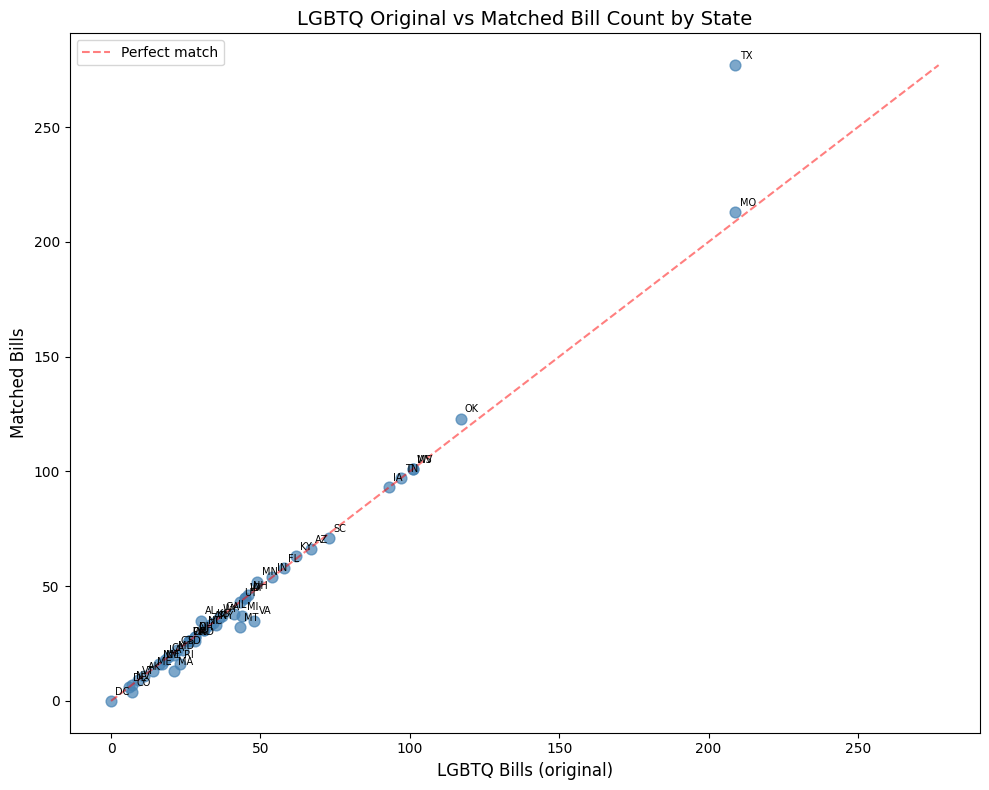

In [28]:

# Merge both count tables on state
plot_df = all_states_df.copy()
plot_df = plot_df.merge(
    lgbtq_dedup.groupby("state").size().reset_index(name="lgbtq_count"),
    on="state", how="left"
).merge(
    df_matched.groupby("state").size().reset_index(name="matched_count"),
    on="state", how="left"
).fillna(0)

plot_df["lgbtq_count"]   = plot_df["lgbtq_count"].astype(int)
plot_df["matched_count"] = plot_df["matched_count"].astype(int)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(plot_df["lgbtq_count"], plot_df["matched_count"], color="steelblue", alpha=0.7, s=60)

# State labels
for _, row in plot_df.iterrows():
    ax.annotate(row["state"], (row["lgbtq_count"], row["matched_count"]),
                fontsize=7, ha="left", va="bottom", xytext=(3, 3),
                textcoords="offset points")

# Diagonal reference line (perfect match)
max_val = max(plot_df["lgbtq_count"].max(), plot_df["matched_count"].max())
ax.plot([0, max_val], [0, max_val], "r--", alpha=0.5, label="Perfect match")

ax.set_xlabel("LGBTQ Bills (original)", fontsize=12)
ax.set_ylabel("Matched Bills", fontsize=12)
ax.set_title("LGBTQ Original vs Matched Bill Count by State", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:


# Counts in merged df
merged_counts = df_matched.groupby("state").size().reset_index(name="count_merged")
merged_counts = all_states_df.merge(merged_counts, on="state", how="left").fillna(0)
merged_counts["count_merged"] = merged_counts["count_merged"].astype(int)

# Find missing states in merged
missing_states = merged_counts[merged_counts["count_merged"] == 0]["state"].tolist()
print(f"States missing from df_merged ({len(missing_states)}): {missing_states}\n")

# Check if missing states exist in df
print("=== In df (bills dataframe) ===")
df_check = df[df["state"].isin(missing_states)].groupby("state").size().reset_index(name="count_df")
print(df_check.to_string() if len(df_check) > 0 else "None found")

# Check if missing states exist in lgbtq
print("\n=== In lgbtq (labels dataframe) ===")
# Try common state column names in lgbtq
for col in ["state", "State", "state_code"]:
    if col in lgbtq.columns:
        lgbtq_check = lgbtq[lgbtq[col].isin(missing_states)].groupby(col).size().reset_index(name="count_lgbtq")
        print(lgbtq_check.to_string() if len(lgbtq_check) > 0 else "None found")
        break

States missing from df_merged (1): ['DC']

=== In df (bills dataframe) ===
  state  count_df
0    DC      6284

=== In lgbtq (labels dataframe) ===
None found


In [30]:
# Verify: check bills that were previously unmatched
# Use normalized bill numbers (leading zeros already stripped)
test_cases = [
    ('TN', 'SB657'),
    ('TN', 'HB578'),
    ('TN', 'HB3'),
    ('TN', 'SB228'),
    ('TN', 'HB529'),
    ('SC', 'S531'),
]

for state, bill in test_cases:
    ls = df[(df['state'] == state) & (df['bill_number'] == bill)][
        ['state', 'session_year', 'year', 'bill_number',
         'session_id', 'status_date']
    ].drop_duplicates()
    lgbtq_rows = lgbtq[
        (lgbtq['state'] == state) & (lgbtq['bill_number'] == bill)
    ][['state', 'year', 'bill_number', 'source']]

    print(f"\n--- {state} {bill} ---")
    if len(lgbtq_rows) > 0:
        print(f"  LGBTQ+ data: years={sorted(lgbtq_rows['year'].tolist())}, "
              f"sources={lgbtq_rows['source'].unique().tolist()}")
    else:
        print(f"  LGBTQ+ data: not found")
    print(f"  LegiScan:")
    for _, r in ls.head(3).iterrows():
        print(f"    session_year={r['session_year']}, status_year={r['year']}, "
              f"status_date={r['status_date']}")

    in_merged = merged[
        (merged['state'] == state) & (merged['bill_number'] == bill) &
        (merged['label'].notna())
    ]
    print(f"  Matched in merged: {len(in_merged)} rows")


--- TN SB657 ---
  LGBTQ+ data: years=[2021], sources=['aclu']
  LegiScan:
    session_year=2021, status_year=2021, status_date=2021-02-09
    session_year=2023, status_year=2023, status_date=2023-05-03
    session_year=2025, status_year=2025, status_date=2025-05-13
  Matched in merged: 1 rows

--- TN HB578 ---
  LGBTQ+ data: years=[2021], sources=['aclu']
  LegiScan:
    session_year=2021, status_year=2021, status_date=2021-02-05
    session_year=2023, status_year=2023, status_date=2023-01-26
    session_year=2025, status_year=2025, status_date=2025-05-27
  Matched in merged: 1 rows

--- TN HB3 ---
  LGBTQ+ data: years=[2021], sources=['aclu']
  LegiScan:
    session_year=2021, status_year=2021, status_date=2021-04-06
    session_year=2023, status_year=2022, status_date=2022-11-17
    session_year=2025, status_year=2024, status_date=2024-11-06
  Matched in merged: 1 rows

--- TN SB228 ---
  LGBTQ+ data: years=[2021], sources=['aclu']
  LegiScan:
    session_year=2021, status_year=202

In [31]:
# ============================================================
# PROFILE THE MATCHED LGBTQ+ BILLS (ACLU + Plural)
# ============================================================
labeled_bills = merged[merged['label'].notna()].copy()

print(f"\n{'='*50}")
print(f"LGBTQ+ MATCHED BILLS PROFILE")
print(f"{'='*50}")
print(f"Total matched: {len(labeled_bills)}")

# --- Label Distribution ---
print(f"\n--- Label Distribution ---")
print(labeled_bills['label'].value_counts())

# --- Source Distribution ---
print(f"\n--- Source Distribution ---")
print(labeled_bills['label_source'].value_counts())

# --- By State (top 15) ---
print(f"\n--- By State (top 15) ---")
print(labeled_bills.groupby('state')['label'].value_counts().unstack(fill_value=0).head(15))

# --- By Year ---
print(f"\n--- By Year ---")
print(labeled_bills.groupby('year')['label'].value_counts().unstack(fill_value=0))

# --- Status Distribution by Label ---
print(f"\n--- Status Distribution ---")
print(labeled_bills.groupby('label')['status_desc'].value_counts().unstack(fill_value=0))

# --- Dominant Sponsor Party by Label ---
print(f"\n--- Dominant Sponsor Party by Label ---")
print(labeled_bills.groupby('label')['bill_dominant_party'].value_counts()
      .unstack(fill_value=0))

# Key validation: what % of harmful bills are R-sponsored?
harmful = labeled_bills[labeled_bills['label'] == 'harmful']
supportive = labeled_bills[labeled_bills['label'] == 'supportive']
print(f"\nHarmful bills R-sponsored:    {(harmful['bill_dominant_party'] == 'R').mean():.1%}")
print(f"Supportive bills D-sponsored: {(supportive['bill_dominant_party'] == 'D').mean():.1%}")

# --- State Lean by Label ---
print(f"\n--- State Lean by Label ---")
print(labeled_bills.groupby('label')['state_lean'].value_counts()
      .unstack(fill_value=0))

# --- Pass Rate by Label ---
print(f"\n--- Pass Rate by Label ---")
print(f"Harmful:    {harmful['passed'].mean():.1%}")
print(f"Supportive: {supportive['passed'].mean():.1%}")

print(f"\nHarmful pass rate by state lean:")
print(harmful.groupby('state_lean')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('pass_rate', ascending=False))

print(f"\nSupportive pass rate by state lean:")
print(supportive.groupby('state_lean')['passed'].agg(['mean', 'count'])
      .rename(columns={'mean': 'pass_rate', 'count': 'n_bills'})
      .sort_values('pass_rate', ascending=False))

# --- Committee Distribution (top 15) ---
print(f"\n--- Committee Distribution (top 15) ---")
print(labeled_bills['committee'].value_counts().head(15))

# --- Sample Titles by Label ---
print(f"\n--- Sample Harmful Bills ---")
print(harmful[['state', 'bill_number', 'title', 'bill_dominant_party', 'state_lean']]
      .head(10).to_string(index=False))

print(f"\n--- Sample Supportive Bills ---")
print(supportive[['state', 'bill_number', 'title', 'bill_dominant_party', 'state_lean']]
      .head(10).to_string(index=False))


LGBTQ+ MATCHED BILLS PROFILE
Total matched: 2354

--- Label Distribution ---
label
harmful       2097
supportive     257
Name: count, dtype: int64

--- Source Distribution ---
label_source
aclu      2037
plural     317
Name: count, dtype: int64

--- By State (top 15) ---
label  harmful  supportive
state                     
AK           9           2
AL          35           0
AR          32           1
AZ          58           8
CA           8          11
CO           4           0
CT          17           5
DE           6           0
FL          52           6
GA          34           3
HI          20          11
IA          91           2
ID          41           4
IL          28          10
IN          51           3

--- By Year ---
label  harmful  supportive
year                      
2020         3           5
2021       161          34
2022       158          53
2023       480           0
2024       420          19
2025       732         146
2026       140           0

--- Sta

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# PROFILE LGBTQ+-LABELED BILLS (ACLU + Plural)
# ============================================================
labeled_bills = merged[merged['label'].notna()].copy()

print(f"Total labeled LGBTQ+ bills: {len(labeled_bills):,}")
print(f"\n--- Label Distribution ---")
print(labeled_bills['label'].value_counts())
print(f"\n--- Source Distribution ---")
print(labeled_bills['label_source'].value_counts())

# ============================================================
# RULE-BASED STANCE CLASSIFIER
# Validate: does sponsor party predict ACLU label?
# ============================================================


def classify_stance(row):
    party = row['bill_dominant_party']
    if party == 'R':
        return 'likely_harmful'
    elif party == 'D':
        return 'likely_supportive'
    else:
        return 'ambiguous'


labeled_bills['predicted'] = labeled_bills.apply(classify_stance, axis=1)

# Map to simple labels for comparison
pred_to_simple = {
    'likely_harmful':    'harmful',
    'likely_supportive': 'supportive',
    'ambiguous':         'ambiguous'
}
labeled_bills['predicted_label'] = labeled_bills['predicted'].map(pred_to_simple)

# ============================================================
# ACCURACY CHECK: heuristic vs ground truth labels
# ============================================================
non_ambiguous = labeled_bills[labeled_bills['predicted_label'] != 'ambiguous']
correct = (non_ambiguous['predicted_label'] == non_ambiguous['label']).sum()
total = len(non_ambiguous)

print(f"\n{'='*50}")
print(f"HEURISTIC ACCURACY (sponsor party → stance)")
print(f"{'='*50}")
print(f"Non-ambiguous predictions: {total}")
print(f"Correct: {correct} ({correct/total:.1%})")
print(f"Ambiguous (bipartisan/other): {len(labeled_bills) - total}")

# Confusion matrix
print(f"\n--- Confusion Matrix ---")
print(pd.crosstab(
    non_ambiguous['label'],
    non_ambiguous['predicted_label'],
    rownames=['Actual'],
    colnames=['Predicted']
))

# Breakdown by label
for label in ['harmful', 'supportive']:
    subset = labeled_bills[labeled_bills['label'] == label]
    print(f"\n--- {label.upper()} bills ---")
    print(f"  Total: {len(subset)}")
    print(f"  Sponsor party distribution:")
    print(f"  {subset['bill_dominant_party'].value_counts().to_string()}")
    print(f"  Heuristic prediction:")
    print(f"  {subset['predicted'].value_counts().to_string()}")

# ============================================================
# BY STATE LEAN
# ============================================================
print(f"\n--- Accuracy by State Lean ---")
for lean in ['Strong R', 'Lean R', 'Competitive', 'Lean D', 'Strong D']:
    sub = non_ambiguous[non_ambiguous['state_lean'] == lean]
    if len(sub) > 0:
        acc = (sub['predicted_label'] == sub['label']).mean()
        print(f"  {lean:12s}: {acc:.1%} ({len(sub)} bills)")

# ============================================================
# SAMPLE MISCLASSIFICATIONS
# ============================================================
misclassified = non_ambiguous[non_ambiguous['predicted_label']
                              != non_ambiguous['label']]
print(f"\n--- Misclassified Bills ({len(misclassified)}) ---")
if len(misclassified) > 0:
    print(misclassified[['state', 'bill_number', 'title', 'label',
                         'predicted_label', 'bill_dominant_party', 'state_lean']]
          .head(15).to_string(index=False))

Total labeled LGBTQ+ bills: 2,354

--- Label Distribution ---
label
harmful       2097
supportive     257
Name: count, dtype: int64

--- Source Distribution ---
label_source
aclu      2037
plural     317
Name: count, dtype: int64

HEURISTIC ACCURACY (sponsor party → stance)
Non-ambiguous predictions: 2209
Correct: 2150 (97.3%)
Ambiguous (bipartisan/other): 145

--- Confusion Matrix ---
Predicted   harmful  supportive
Actual                         
harmful        1916          45
supportive       14         234

--- HARMFUL bills ---
  Total: 2097
  Sponsor party distribution:
  bill_dominant_party
R             1916
Other          126
D               45
Bipartisan      10
  Heuristic prediction:
  predicted
likely_harmful       1916
ambiguous             136
likely_supportive      45

--- SUPPORTIVE bills ---
  Total: 257
  Sponsor party distribution:
  bill_dominant_party
D             234
R              14
Other           8
Bipartisan      1
  Heuristic prediction:
  predicted
likel

## EDA: LGBTQ+ Legislative Landscape

Key analyses:
1. **Legislative wave** — bill volume by state × year heatmap
2. **Bill outcomes by state lean** — where do these bills actually pass?
3. **Action count as deliberation proxy** — quiet deaths vs. real debate
4. **Pass rate asymmetry** — restrictive bills in red states vs. protective in blue

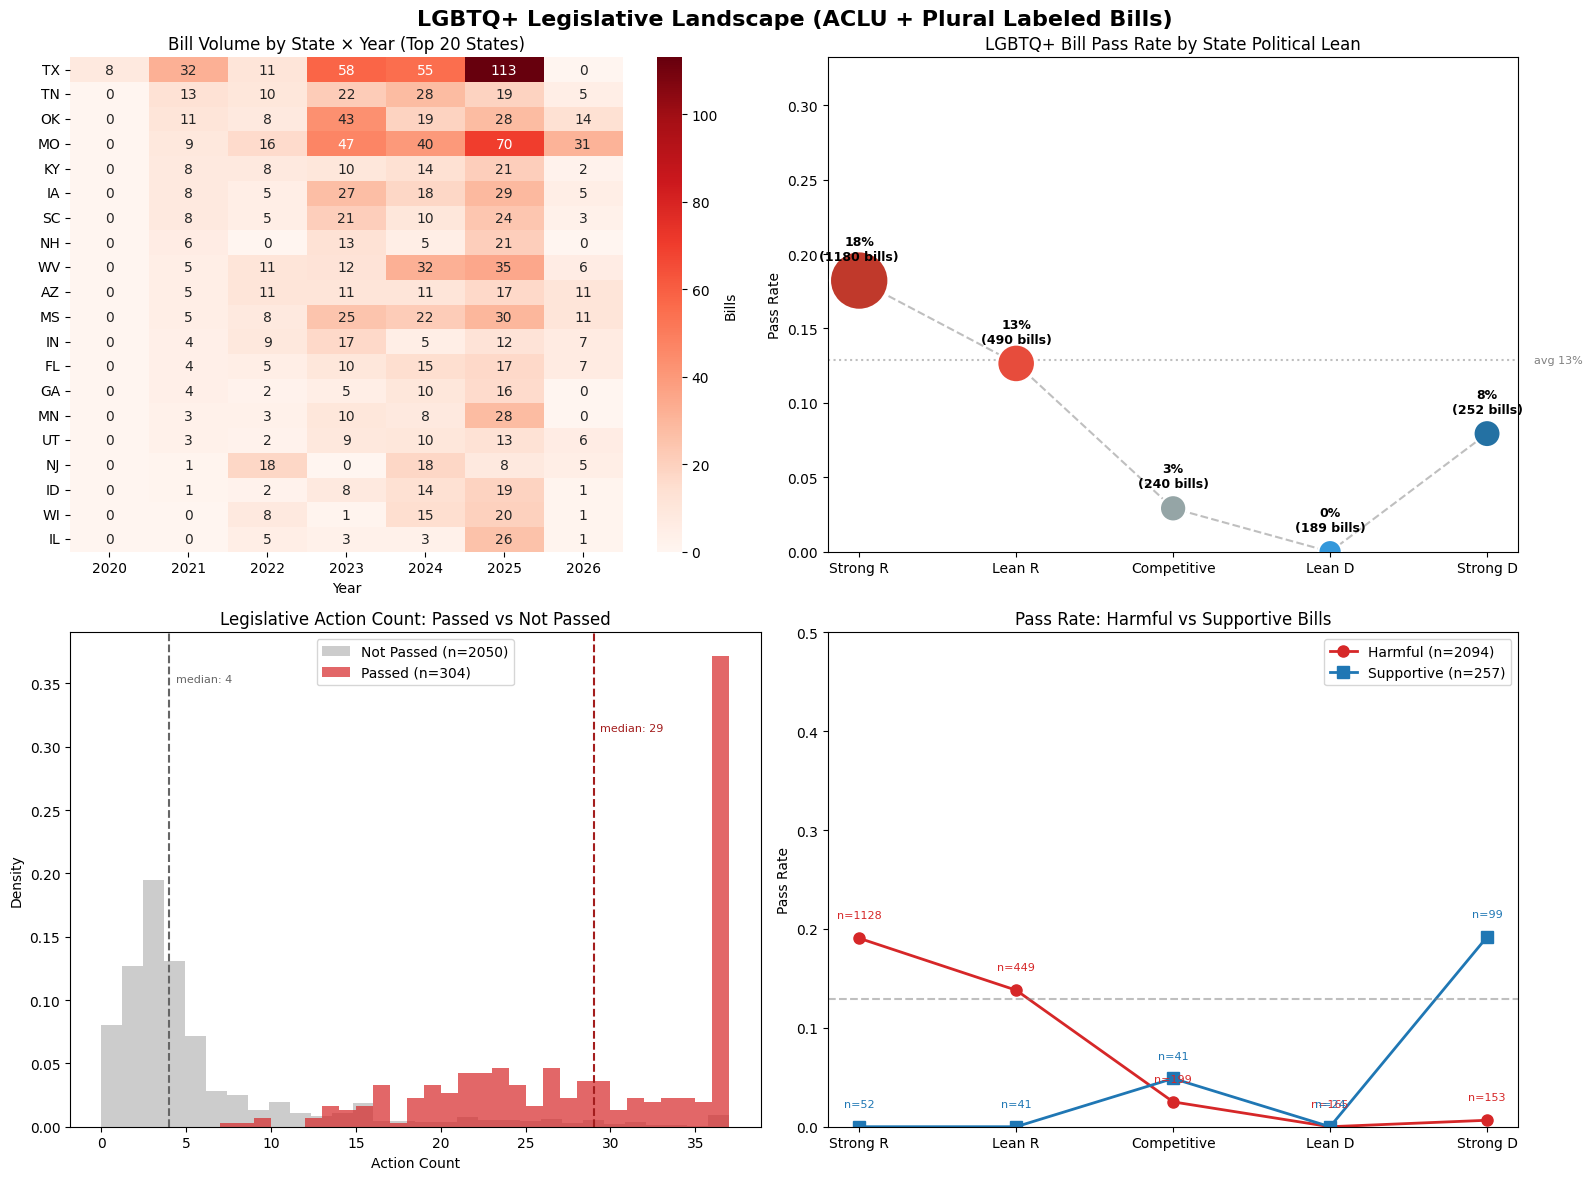


Saved: lgbtq_eda.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labeled_bills = merged[merged['label'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LGBTQ+ Legislative Landscape (ACLU + Plural Labeled Bills)',
             fontsize=16, fontweight='bold')

# ============================================================
# 1. Legislative Wave — Bill Volume by State × Year Heatmap
# ============================================================
ax = axes[0, 0]
pivot = labeled_bills.groupby(['state', 'year']).size().unstack(fill_value=0)
# Top 20 states by total volume
top_states = pivot.sum(axis=1).nlargest(20).index
pivot_top = pivot.loc[top_states].sort_values(
    by=list(pivot.columns), ascending=False)

sns.heatmap(pivot_top, annot=True, fmt='d', cmap='Reds',
            ax=ax, cbar_kws={'label': 'Bills'})
ax.set_title('Bill Volume by State × Year (Top 20 States)')
ax.set_xlabel('Year')
ax.set_ylabel('')

# ============================================================
# 2. Bill Outcomes by State Lean — Pass Rate Dot Plot
# ============================================================
ax = axes[0, 1]
lean_order = ['Strong R', 'Lean R', 'Competitive', 'Lean D', 'Strong D']
lean_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#3498db', '#2471a3']

stats = labeled_bills.groupby('state_lean').agg(
    n_bills=('bill_id', 'count'),
    pass_rate=('passed', 'mean'),
).reindex(lean_order)

ax.scatter(range(len(lean_order)), stats['pass_rate'],
           s=stats['n_bills'] * 1.5, c=lean_colors, zorder=3, edgecolors='white', linewidth=1.5)

# Connect with line
ax.plot(range(len(lean_order)),
        stats['pass_rate'], color='gray', linestyle='--', alpha=0.5, zorder=2)

# Annotate
for i, (lean, row) in enumerate(stats.iterrows()):
    ax.annotate(f"{row['pass_rate']:.0%}\n({int(row['n_bills'])} bills)",
                xy=(i, row['pass_rate']), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(lean_order)))
ax.set_xticklabels(lean_order)
ax.set_title('LGBTQ+ Bill Pass Rate by State Political Lean')
ax.set_ylabel('Pass Rate')
ax.set_ylim(0, max(stats['pass_rate']) + 0.15)
ax.axhline(y=labeled_bills['passed'].mean(),
           color='gray', linestyle=':', alpha=0.5)
ax.text(4.3, labeled_bills['passed'].mean(), f"avg {labeled_bills['passed'].mean():.0%}",
        fontsize=8, color='gray', va='center')

# ============================================================
# 3. Action Count — Density: Passed vs Not Passed
# ============================================================
ax = axes[1, 0]
cap = int(labeled_bills['action_count'].quantile(0.95))

passed = labeled_bills[labeled_bills['passed'] ==
                    True]['action_count'].clip(upper=cap)
not_passed = labeled_bills[labeled_bills['passed']
                        == False]['action_count'].clip(upper=cap)

ax.hist(not_passed, bins=30, alpha=0.6, color='#aaaaaa',
        label=f'Not Passed (n={len(not_passed)})', density=True)
ax.hist(passed, bins=30, alpha=0.7, color='#d62728',
        label=f'Passed (n={len(passed)})', density=True)

# Add median lines
ax.axvline(not_passed.median(), color='#666666', linestyle='--', linewidth=1.5)
ax.axvline(passed.median(), color='#a31d1d', linestyle='--', linewidth=1.5)

ax.annotate(f'median: {not_passed.median():.0f}', xy=(not_passed.median(), ax.get_ylim()[1] * 0.9),
            fontsize=8, color='#666666', ha='left', xytext=(5, 0), textcoords='offset points')
ax.annotate(f'median: {passed.median():.0f}', xy=(passed.median(), ax.get_ylim()[1] * 0.8),
            fontsize=8, color='#a31d1d', ha='left', xytext=(5, 0), textcoords='offset points')

ax.set_title('Legislative Action Count: Passed vs Not Passed')
ax.set_xlabel('Action Count')
ax.set_ylabel('Density')
ax.legend()

# ============================================================
# 4. Pass Rate Asymmetry — Harmful vs Supportive by State Lean
# ============================================================
ax = axes[1, 1]
pass_rates = labeled_bills.groupby(['state_lean', 'label'])[
    'passed'].agg(['mean', 'count']).reset_index()
pass_rates.columns = ['state_lean', 'label', 'pass_rate', 'n_bills']
pass_rates = pass_rates[pass_rates['n_bills'] >= 3]  # min sample size

for label, color, marker in [('harmful', '#d62728', 'o'), ('supportive', '#1f77b4', 's')]:
    sub = pass_rates[pass_rates['label'] == label].set_index(
        'state_lean').reindex(lean_order)
    ax.plot(range(len(sub)), sub['pass_rate'], marker=marker, color=color,
            label=f'{label.title()} (n={sub["n_bills"].sum():.0f})', linewidth=2, markersize=8)
    # Annotate sample sizes
    for i, (lean, row) in enumerate(sub.iterrows()):
        if pd.notna(row['pass_rate']):
            ax.annotate(f'n={row["n_bills"]:.0f}', xy=(i, row['pass_rate'] + 0.02),
                        ha='center', fontsize=8, color=color)

ax.set_xticks(range(len(lean_order)))
ax.set_xticklabels(lean_order)
ax.set_title('Pass Rate: Harmful vs Supportive Bills')
ax.set_ylabel('Pass Rate')
ax.set_ylim(0, 0.5)
ax.legend()
ax.axhline(y=labeled_bills['passed'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Overall')

plt.tight_layout()
plt.savefig('lgbtq_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: lgbtq_eda.png")

In [34]:
print(labeled_bills.columns)
print(len(labeled_bills.columns))

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count',
       'document_types', 'document_urls', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'passed', 'failed', 'vetoed', 'state_lean',
       'r_sponsorship_ratio', 'pass_rate_gap', 'overall_pass_rate',
       'bipartisan_ratio', 'session_year', 'label', 'label_source', 'issues',
       'issue_categories'],
      dtype='object')
45
